In [ ]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd() / "src"))
import warnings

warnings.filterwarnings("ignore")

In [ ]:
from src.data.download import download_xenium_dataset

url = "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_TgCRND8_17_9_months/Xenium_V1_FFPE_TgCRND8_17_9_months_outs.zip"
output_dir = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/xenium_raw"

download_xenium_dataset(url, output_dir)

'src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/xenium_raw'

In [ ]:
from src.scripts.preprocessing.loaders import load_cells_table, load_expression_matrix

cells_path = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/xenium_raw/cells.parquet"
expr_path = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/xenium_raw/cell_feature_matrix.h5"

cells_df = load_cells_table(cells_path)
adata = load_expression_matrix(expr_path)

Original: 62268 cells → Filtered: 56962 cells


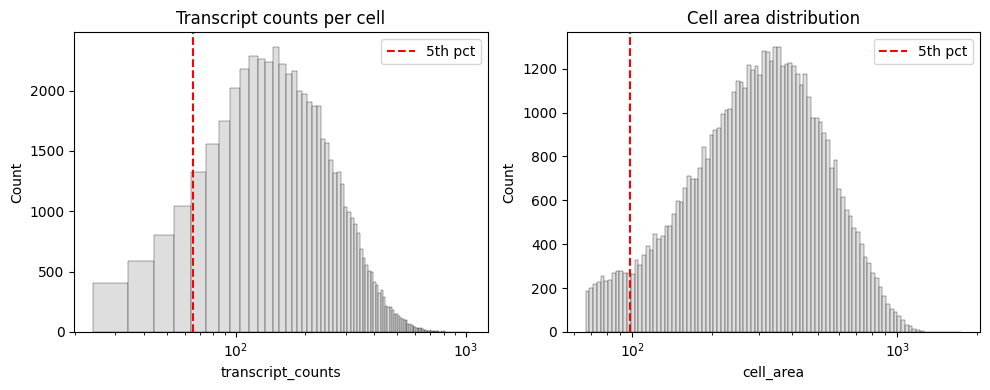

In [ ]:
from src.scripts.preprocessing.qc import filter_cells, plot_qc_distributions

filtered_cells_df = filter_cells(cells_df, transcript_q=0.05, area_q=0.05)

print(f"Original: {cells_df.shape[0]} cells → Filtered: {filtered_cells_df.shape[0]} cells")

plot_qc_distributions(filtered_cells_df, transcript_q=0.05, area_q=0.05)

In [ ]:
from src.scripts.preprocessing.plaque_distance import (
    compute_cell_to_plaque_distance,
    load_plaque_polygons,
)

# Paths

plaques_path = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/plaque_polygons.csv"
plaques_gdf = load_plaque_polygons(plaques_path)

# Compute per-cell distances
cells_with_dist = compute_cell_to_plaque_distance(filtered_cells_df, plaques_gdf)

cells_with_dist.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,total_counts,cell_area,nucleus_area,distance_to_plaque
0,b'aaabiggh-1',831.785336,755.803772,554,0,0,0,554,509.091563,65.386250,35.775568
1,b'aaacfoel-1',821.733453,768.910446,291,0,0,0,291,275.498281,36.982969,37.307845
2,b'aaaeefil-1',831.932053,780.367651,220,1,0,0,221,261.635312,15.849844,23.175138
3,b'aaaehidd-1',853.614108,774.764157,1029,0,0,0,1029,818.547344,129.056563,7.126988
4,b'aaagcbkg-1',821.639603,799.171515,453,0,0,1,454,522.232031,96.002188,26.299783


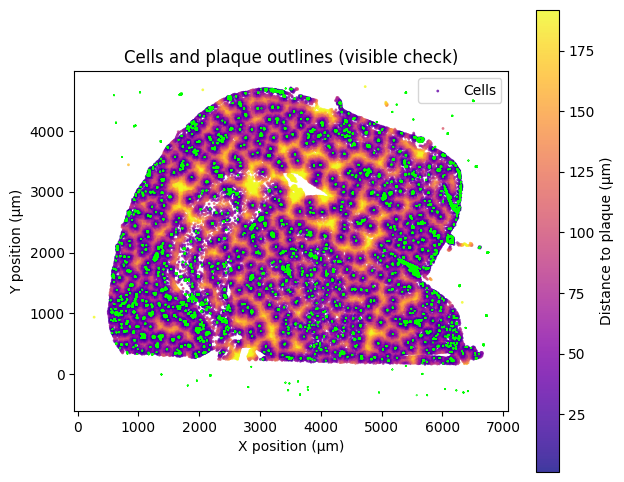

In [ ]:
from src.scripts.preprocessing.plaque_distance import plot_cell_to_plaque_map_visible

plot_cell_to_plaque_map_visible(cells_with_dist, plaques_gdf)

In [ ]:
from src.scripts.preprocessing.loaders import merge_expression_with_cells

combined_df = merge_expression_with_cells(cells_with_dist, adata)
combined_df.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,total_counts,cell_area,nucleus_area,...,Unc13c,Vat1l,Vcan,Vim,Vip,Vwc2l,Wfs1,Zfp366,Zfp536,Zfpm2
0,aaabiggh-1,831.785336,755.803772,554,0,0,0,554,509.091563,65.386250,...,0,4.293225,0,0,0,4.010086,0,0,0,2.947095
1,aaacfoel-1,821.733453,768.910446,291,0,0,0,291,275.498281,36.982969,...,0,0,0,3.565702,0,4.244609,0,0,0,3.565702
2,aaaeefil-1,831.932053,780.367651,220,1,0,0,221,261.635312,15.849844,...,3.838474,0,0,0,0,0,3.838474,0,0,4.5208
3,aaaehidd-1,853.614108,774.764157,1029,0,0,0,1029,818.547344,129.056563,...,0,4.36622,0,2.371941,0,3.685692,3.685692,0,0,3.017315
4,aaagcbkg-1,821.639603,799.171515,453,0,0,1,454,522.232031,96.002188,...,0,3.809993,0,4.208048,0,0,0,0,0,3.809993


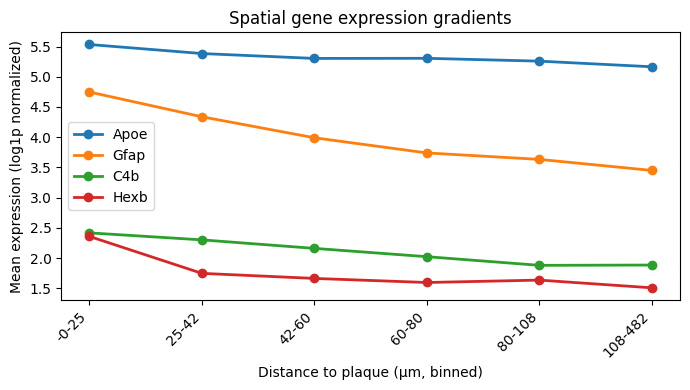

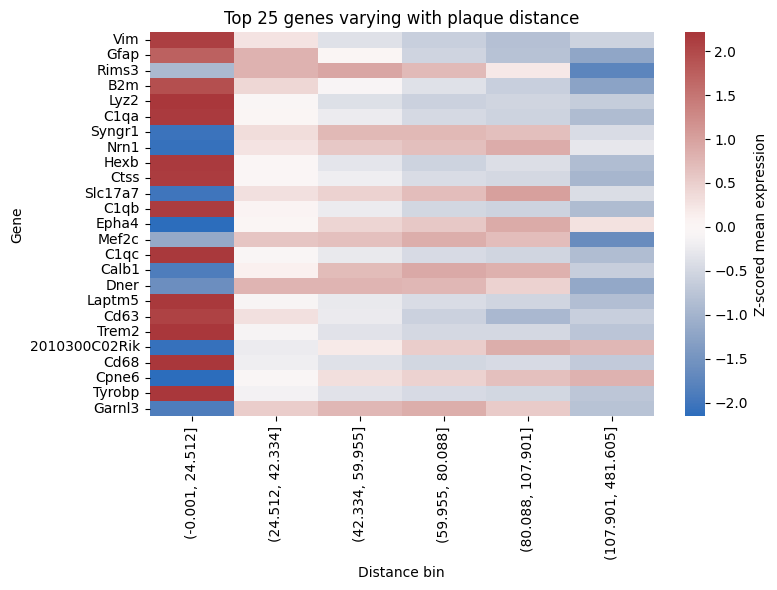

In [ ]:
from src.scripts.preprocessing.spatial_trends import (
    assign_distance_bins,
    mean_expression_by_bin,
    plot_gene_trends,
    plot_mean_heatmap,
)

combined_binned = assign_distance_bins(combined_df, n_bins=6)

gene_cols = [
    c
    for c in combined_df.columns
    if c
    not in [
        "cell_id",
        "x_centroid",
        "y_centroid",
        "cell_area",
        "transcript_counts",
        "distance_to_plaque",
        "distance_bin",
    ]
]

mean_expr = mean_expression_by_bin(combined_binned, gene_cols)

# Plot trends for known PIG genes
plot_gene_trends(mean_expr, ["Apoe", "Gfap", "C4b", "Hexb"])

# Visualize top genes with spatial gradients
plot_mean_heatmap(mean_expr, top_n=25)

,gene,spearman_r,spearman_p,slope,fdr_pval
4,2010300C02Rik,0.101102,2.755779e-129,0.004482,4.205559e-128
79,Cpne6,0.094013,5.544154e-112,0.004041,6.710338e-111
255,Ppp1r1b,0.093159,5.537538e-110,0.004146,6.269923e-109
308,Spag16,0.082213,5.306023e-86,0.002563,4.901090e-85
26,Bcl11b,0.081766,4.362960e-85,0.002859,3.828497e-84
290,Sipa1l3,0.080421,2.304492e-82,0.003273,1.972870e-81
191,Mdga1,0.080396,2.582144e-82,0.002148,2.157934e-81
195,Meis2,0.078732,5.227506e-79,0.003554,3.988814e-78
228,Orai2,0.078184,6.172039e-78,0.002715,4.421196e-77
107,Epha4,0.075359,1.599857e-72,0.003038,1.039907e-71


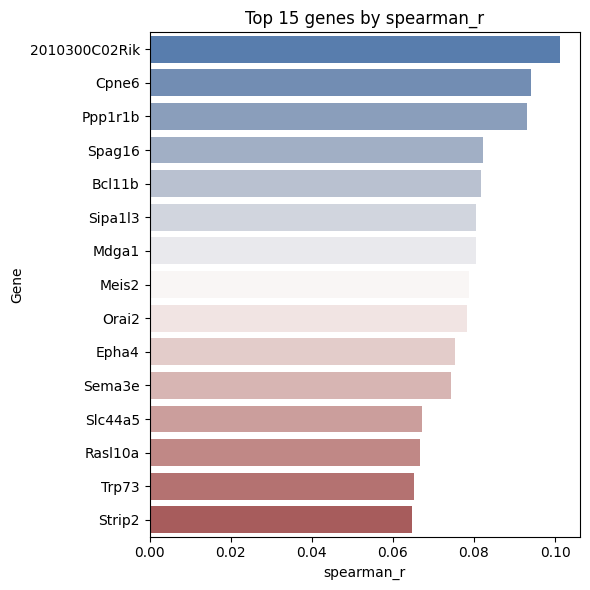

In [ ]:
from src.scripts.analysis.regression_analysis import (
    compute_gene_spatial_stats,
    plot_top_spatial_genes,
)

gene_cols = [
    g
    for g in combined_df.columns
    if g
    not in [
        "cell_id",
        "x_centroid",
        "y_centroid",
        "cell_area",
        "distance_to_plaque",
        "transcript_counts",
        "nucleus_area",
    ]
]

stats_df = compute_gene_spatial_stats(combined_df, gene_cols)

# filter for significant positive correlations
sig_pos = stats_df.query("fdr_pval < 0.05 and spearman_r > 0").head(15)
display(sig_pos)

# visualize only significant ones
plot_top_spatial_genes(sig_pos, top_n=15, metric="spearman_r")

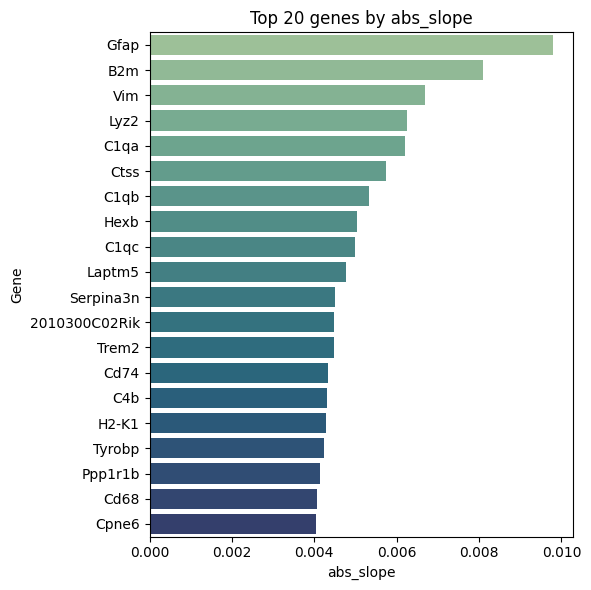

In [ ]:
plot_top_spatial_genes(
    stats_df.query("gene != 'total_counts'").assign(abs_slope=stats_df["slope"].abs()),
    metric="abs_slope",
)